In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tensorflow.keras.utils import Progbar # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, f1, f3_reduce, f3, f5_reduce, f5, pool_proj):
        super().__init__()
        
        self.proj1 = nn.Sequential(
            nn.Conv2d(in_channels, f1, kernel_size=1),
            nn.ReLU(inplace=True)
        )
        
        self.proj2 = nn.Sequential(
            nn.Conv2d(in_channels, f3_reduce, kernel_size=1),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(f3_reduce, f3, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )


        self.proj3 = nn.Sequential(
            nn.Conv2d(in_channels, f5_reduce, kernel_size=1),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(f5_reduce, f5, kernel_size=5, padding=2),
            nn.ReLU(inplace=True)
        )

        self.proj4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        p1 = self.proj1(x)
        p2 = self.proj2(x)
        p3 = self.proj3(x)
        p4 = self.proj4(x)
        
        return torch.cat([p1, p2, p3, p4], dim=1)
        

In [3]:
class AuxiliaryClassifier(nn.Module):
 
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()
        
        # self.pool = nn.AvgPool2d(kernel_size=5, stride=3)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv = nn.Sequential(nn.Conv2d(in_channels, 128, kernel_size=1), nn.ReLU(inplace=True))
        
        self.fc1 = nn.Linear(128 * 2 * 2, 1024)
        self.dropout = nn.Dropout(p=0.7)
        
        self.fc2 = nn.Linear(1024, num_classes)
 
    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x), inplace=True)
        x = self.dropout(x)
        
        return self.fc2(x)

In [4]:
class InceptionNet(nn.Module):
    def __init__(self, num_classes, aux_logits = True, dropout = 0.4):
        super().__init__()
        self.aux_logits = aux_logits

        # self.conv1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3), nn.ReLU(inplace=True))
        # self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.conv1 = nn.Sequential(nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(inplace=True))
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # self.conv2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1), nn.ReLU(inplace=True))
        # self.conv3 = nn.Sequential(nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True))
        # self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.conv2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1), nn.ReLU(inplace=True))
        self.conv3 = nn.Sequential(nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True))
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        in_channels = [192, 256, 480, 512, 512, 512, 528, 832, 832]
        
        feature_maps = [
            [64,  96,  128, 16, 32,  32 ],   # 3a -> 256
            [128, 128, 192, 32, 96,  64 ],   # 3b -> 480
            [192, 96,  208, 16, 48,  64 ],   # 4a -> 512
            [160, 112, 224, 24, 64,  64 ],   # 4b -> 512
            [128, 128, 256, 24, 64,  64 ],   # 4c -> 512
            [112, 144, 288, 32, 64,  64 ],   # 4d -> 528
            [256, 160, 320, 32, 128, 128],   # 4e -> 832
            [256, 160, 320, 32, 128, 128],   # 5a -> 832
            [384, 192, 384, 48, 128, 128],   # 5b -> 1024
        ]

        self.inception3a = InceptionBlock(in_channels[0], *feature_maps[0])
        
        self.inception3b = InceptionBlock(in_channels[1], *feature_maps[1])
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inception4a = InceptionBlock(in_channels[2], *feature_maps[2])
        
        self.inception4b = InceptionBlock(in_channels[3], *feature_maps[3])
        
        self.inception4c = InceptionBlock(in_channels[4], *feature_maps[4])
        
        self.inception4d = InceptionBlock(in_channels[5], *feature_maps[5])
        
        self.inception4e = InceptionBlock(in_channels[6], *feature_maps[6])
        self.pool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inception5a = InceptionBlock(in_channels[7], *feature_maps[7])
        
        self.inception5b = InceptionBlock(in_channels[8], *feature_maps[8])
        
        
        if aux_logits:
            self.aux1 = AuxiliaryClassifier(512, num_classes)  
            self.aux2 = AuxiliaryClassifier(528, num_classes)  

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(1024, num_classes)

        self._initialize_weights()
        
    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv3(self.conv2(x)))

        x = self.pool3(self.inception3b(self.inception3a(x)))

        x = self.inception4a(x)
        aux1_out = self.aux1(x) if self.aux_logits and self.training else None

        x = self.inception4d(self.inception4c(self.inception4b(x)))
        aux2_out = self.aux2(x) if self.aux_logits and self.training else None

        x = self.pool4(self.inception4e(x))
        x = self.inception5b(self.inception5a(x))

        x = self.avgpool(x)
        x = self.fc(self.dropout(x.view(x.size(0), -1)))

        if self.training and self.aux_logits:
            return x, aux1_out, aux2_out
        
        return x
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
                    
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

In [5]:
class InceptionNetLoss(nn.Module):
    def __init__(self, aux_weight: float = 0.3):
        super().__init__()
        self.aux_weight = aux_weight
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, outputs, targets):
        if isinstance(outputs, torch.Tensor):
            return self.loss_fn(outputs, targets)

        main_logits, aux1_logits, aux2_logits = outputs
        loss = self.loss_fn(main_logits, targets)
        
        if aux1_logits is not None:
            loss = loss + self.aux_weight * self.loss_fn(aux1_logits, targets)
            
        if aux2_logits is not None:
            loss = loss + self.aux_weight * self.loss_fn(aux2_logits, targets)
            
        return loss

In [6]:
def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [7]:
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010]),
])

train_dataset = datasets.CIFAR10(root='../data/dataset', train=True,  download=True, transform=train_transform)
val_dataset = datasets.CIFAR10(root='../data/dataset', train=False, download=True, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches : {len(val_loader)}')

Train batches : 782
Val batches : 157


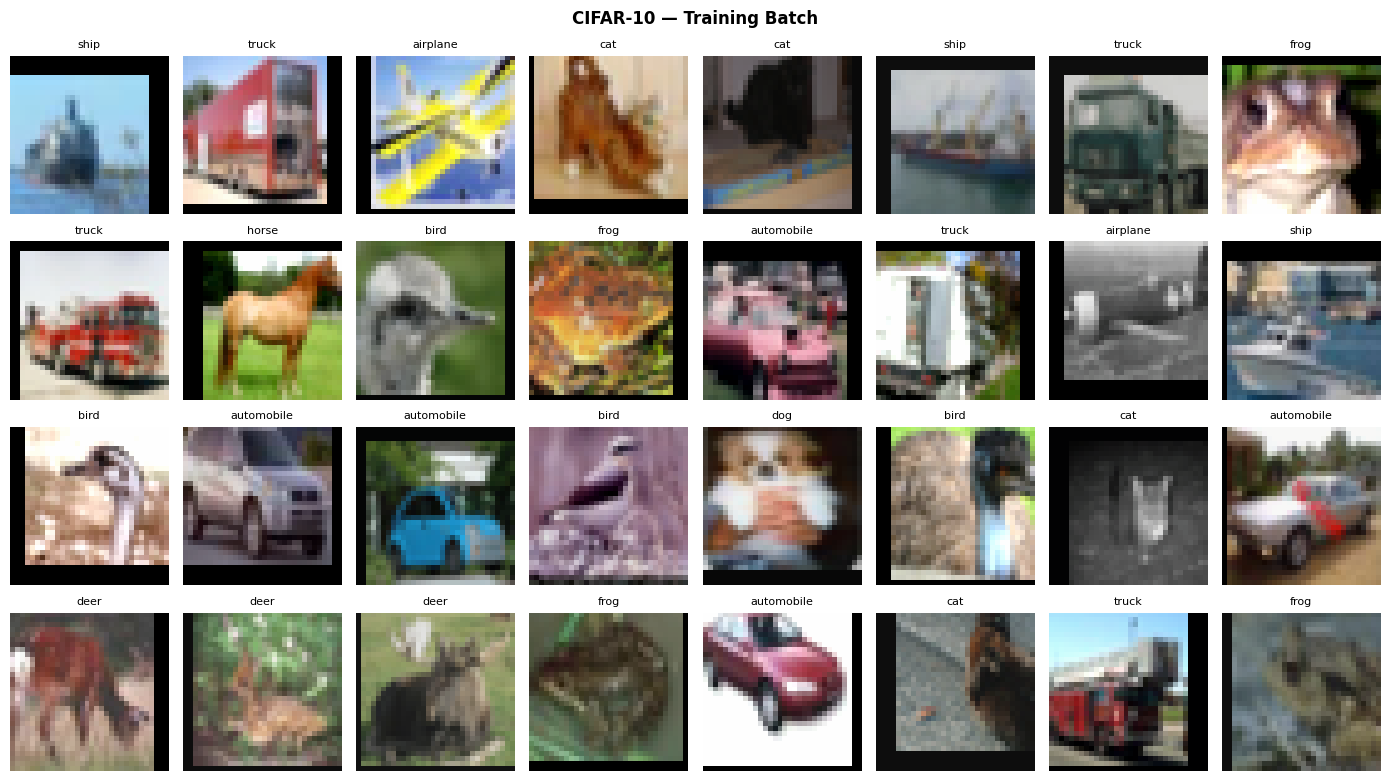

In [10]:
def denormalize(tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img  = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(14, 8))
for ax, img, lbl in zip(axes.flat, images, labels):
    ax.imshow(denormalize(img))
    ax.set_title(train_dataset.classes[lbl], fontsize=8)
    ax.axis("off")

plt.suptitle("CIFAR-10 — Training Batch", fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [ ]:
epochs = 35 
lr = 0.01
momentum = 0.9
weight_decay = 1e-4

In [10]:
model = InceptionNet(num_classes=10, aux_logits=True).to(device)
loss_fn = InceptionNetLoss(aux_weight=0.3)
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.96)

In [11]:
num_train_steps = len(train_loader)
num_val_steps   = len(val_loader)

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1}/{epochs}  (lr={scheduler.get_last_lr()[0]:.6f})')

    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    progbar = Progbar(target=num_train_steps)

    for batch_index, (batch_features, y_true) in enumerate(train_loader, 1):
        batch_features, y_true = batch_features.to(device), y_true.to(device)

        y_pred = model(batch_features)
        loss = loss_fn(y_pred, y_true)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        avg_loss = running_loss / batch_index

        main_logits = y_pred[0] if isinstance(y_pred, tuple) else y_pred
        _, predicted = torch.max(main_logits, 1)
        train_total += y_true.size(0)
        train_correct += (predicted == y_true).sum().item()
        train_acc = train_correct / train_total

        progbar.update(batch_index, values =[('loss', avg_loss), ('acc', train_acc)])

    scheduler.step()


Epoch 1/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - loss: 3.4845 - acc: 0.1586

Epoch 2/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - loss: 2.8011 - acc: 0.3241

Epoch 3/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - loss: 2.3106 - acc: 0.4612

Epoch 4/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - loss: 1.8974 - acc: 0.5751

Epoch 5/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - loss: 1.6499 - acc: 0.6360

Epoch 6/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - loss: 1.4411 - acc: 0.6873

Epoch 7/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 87ms/step - loss: 1.3176 - acc: 0.7186

Epoch 8/35  (lr=0.010000)
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 95ms/step - loss: 1.1875 - acc: 0.7477

Epoch 9/35  (lr=0.009600)
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - loss: 1.0971 - acc: 0.7674

Epoch 10/35  (lr=0.009600)
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - loss: 1.0387 - acc: 0.7804

Epoch 

In [12]:
model.eval()

InceptionNet(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (inception3a): InceptionBlock(
    (proj1): Sequential(
      (0): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
    )
    (proj2): Sequential(
      (0): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (proj3): Sequential(
      (0): Conv2d(192, 16, k

In [13]:
val_loss_sum = 0.0
val_correct  = 0
val_total    = 0
progbar = Progbar(target=num_val_steps)
with torch.no_grad():
    for batch_index, (batch_features, batch_labels) in enumerate(val_loader, 1):
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs      = model(batch_features)   # plain tensor in eval mode
        loss         = loss_fn(outputs, batch_labels)
        val_loss_sum += loss.item()
        avg_val_loss  = val_loss_sum / batch_index
        _, predicted = torch.max(outputs, 1)
        val_total   += batch_labels.size(0)
        val_correct += (predicted == batch_labels).sum().item()
        val_acc      = val_correct / val_total
        progbar.update(batch_index, values=[('val_loss', avg_val_loss), ('val_acc', val_acc)])
print(f'val accuracy: {val_correct}/{val_total} = {val_acc:.4f}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - val_loss: 0.4122 - val_acc: 0.8645
val accuracy: 8645/10000 = 0.8645
